# Shapelet validation: herculens vs lenstronomy

This notebook checks that the herculens Gaussian-Hermite shapelet implementation
(`herculens.LightModel.Profiles.shapelets.Shapelets`) agrees with the reference
lenstronomy implementation (`lenstronomy.LightModel.Profiles.shapelets.ShapeletSet`).

Two levels of comparison are performed:
1. **Individual basis functions** — each $(n_1, n_2)$ pair is compared one by one.
2. **Full shapelet set** — a model built from random amplitudes is compared as a whole.

In [1]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from herculens.LightModel.Profiles.shapelets import Shapelets as HercShapelets
from lenstronomy.LightModel.Profiles.shapelets import ShapeletSet as LSTShapeletSet

## Setup: grid and shapelet parameters

In [2]:
# Coordinate grid (1-D arrays for direct function calls)
n_pix   = 64
fov     = 3.0          # arcsec, half-width
coords  = np.linspace(-fov, fov, n_pix)
XX, YY  = np.meshgrid(coords, coords)
x_flat  = XX.ravel()
y_flat  = YY.ravel()

# Shapelet parameters
n_max    = 20
beta     = 0.8      # arcsec
center_x = 0.0
center_y = 0.0

n_amps   = int((n_max + 1) * (n_max + 2) / 2)
print(f"n_max = {n_max}  →  {n_amps} basis functions")

n_max = 20  →  231 basis functions


## Instantiate both models

In [3]:
herc_model = HercShapelets(n_max=n_max, interpolate=False)
lst_model  = LSTShapeletSet()          # uses pre-calc Hermite polynomials internally

print("herculens num_amplitudes :", herc_model.num_amplitudes)
print("lenstronomy num_param    :", n_amps)

herculens num_amplitudes : 231
lenstronomy num_param    : 231


## 1 — Individual basis functions

For each basis function $i$ we set $a_i = 1$ and all others to $0$, then compare
the herculens and lenstronomy outputs pixel by pixel.

In [4]:
max_abs_errors = []
rel_rms_errors = []

for i in range(n_amps):
    # --- herculens ---
    amps_i = np.zeros(n_amps)
    amps_i[i] = 1.0
    herc_out = np.array(herc_model.function(
        x_flat, y_flat,
        beta=beta, center_x=center_x, center_y=center_y,
        amps=jnp.array(amps_i),
    ))

    # --- lenstronomy ---
    lst_out = lst_model.function(
        x_flat, y_flat,
        amp=amps_i, n_max=n_max,
        beta=beta, center_x=center_x, center_y=center_y,
    )

    print(f'--- {i} ---')
    print('Herculens', herc_out)
    print('Lenstronomy', lst_out)
    diff = herc_out - lst_out
    max_abs_errors.append(np.max(np.abs(diff)))
    denom = np.sqrt(np.mean(lst_out**2))
    rel_rms_errors.append(np.sqrt(np.mean(diff**2)) / denom if denom > 0 else 0.0)

print(f"Max absolute error over all basis functions : {max(max_abs_errors):.2e}")
print(f"Max relative RMS error over all basis functions : {max(rel_rms_errors):.2e}")

--- 0 ---
Herculens [4.4071595e-07 6.8385305e-07 1.0461928e-06 ... 1.0461928e-06 6.8385305e-07
 4.4071595e-07]
Lenstronomy [4.40716096e-07 6.83853216e-07 1.04619324e-06 ... 1.04619324e-06
 6.83853216e-07 4.40716096e-07]
--- 1 ---
Herculens [-2.3372495e-06 -3.5115461e-06 -5.1960046e-06 ...  5.1960046e-06
  3.5115461e-06  2.3372495e-06]
Lenstronomy [-2.33725005e-06 -3.51154667e-06 -5.19600590e-06 ...  5.19600590e-06
  3.51154667e-06  2.33725005e-06]
--- 2 ---
Herculens [-2.3372495e-06 -3.6266788e-06 -5.5482760e-06 ...  5.5482760e-06
  3.6266788e-06  2.3372495e-06]
Lenstronomy [-2.33725005e-06 -3.62667935e-06 -5.54827749e-06 ...  5.54827749e-06
  3.62667935e-06  2.33725005e-06]
--- 3 ---
Herculens [8.4530511e-06 1.2266699e-05 1.7508100e-05 ... 1.7508100e-05 1.2266699e-05
 8.4530511e-06]
Lenstronomy [8.45305434e-06 1.22667015e-05 1.75081075e-05 ... 1.75081075e-05
 1.22667015e-05 8.45305434e-06]
--- 4 ---
Herculens [1.2395140e-05 1.8622790e-05 2.7555981e-05 ... 2.7555981e-05 1.8622790e-05
 

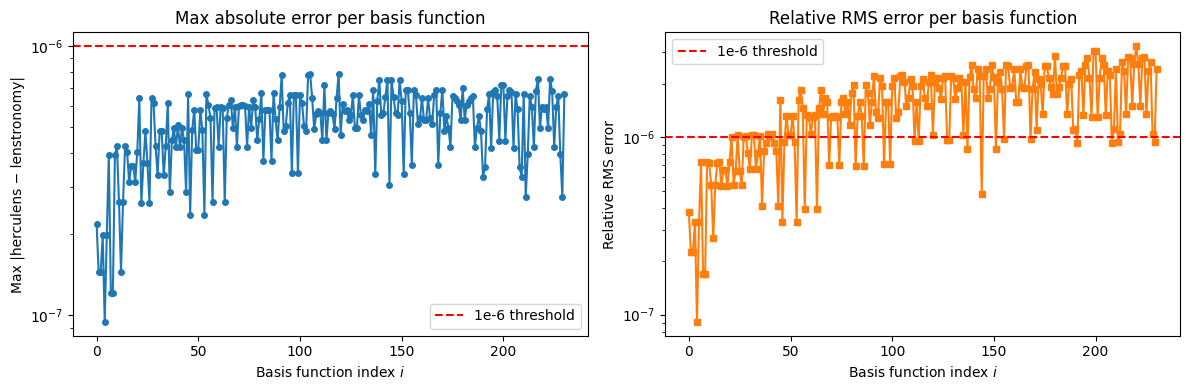

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(max_abs_errors, 'o-', ms=4)
axes[0].set_xlabel("Basis function index $i$")
axes[0].set_ylabel("Max |herculens − lenstronomy|")
axes[0].set_title("Max absolute error per basis function")
axes[0].axhline(1e-6, color='r', ls='--', label='1e-6 threshold')
axes[0].legend()
axes[0].set_yscale('log')

axes[1].plot(rel_rms_errors, 's-', ms=4, color='C1')
axes[1].set_xlabel("Basis function index $i$")
axes[1].set_ylabel("Relative RMS error")
axes[1].set_title("Relative RMS error per basis function")
axes[1].axhline(1e-6, color='r', ls='--', label='1e-6 threshold')
axes[1].legend()
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

### Visual comparison of a few individual basis functions

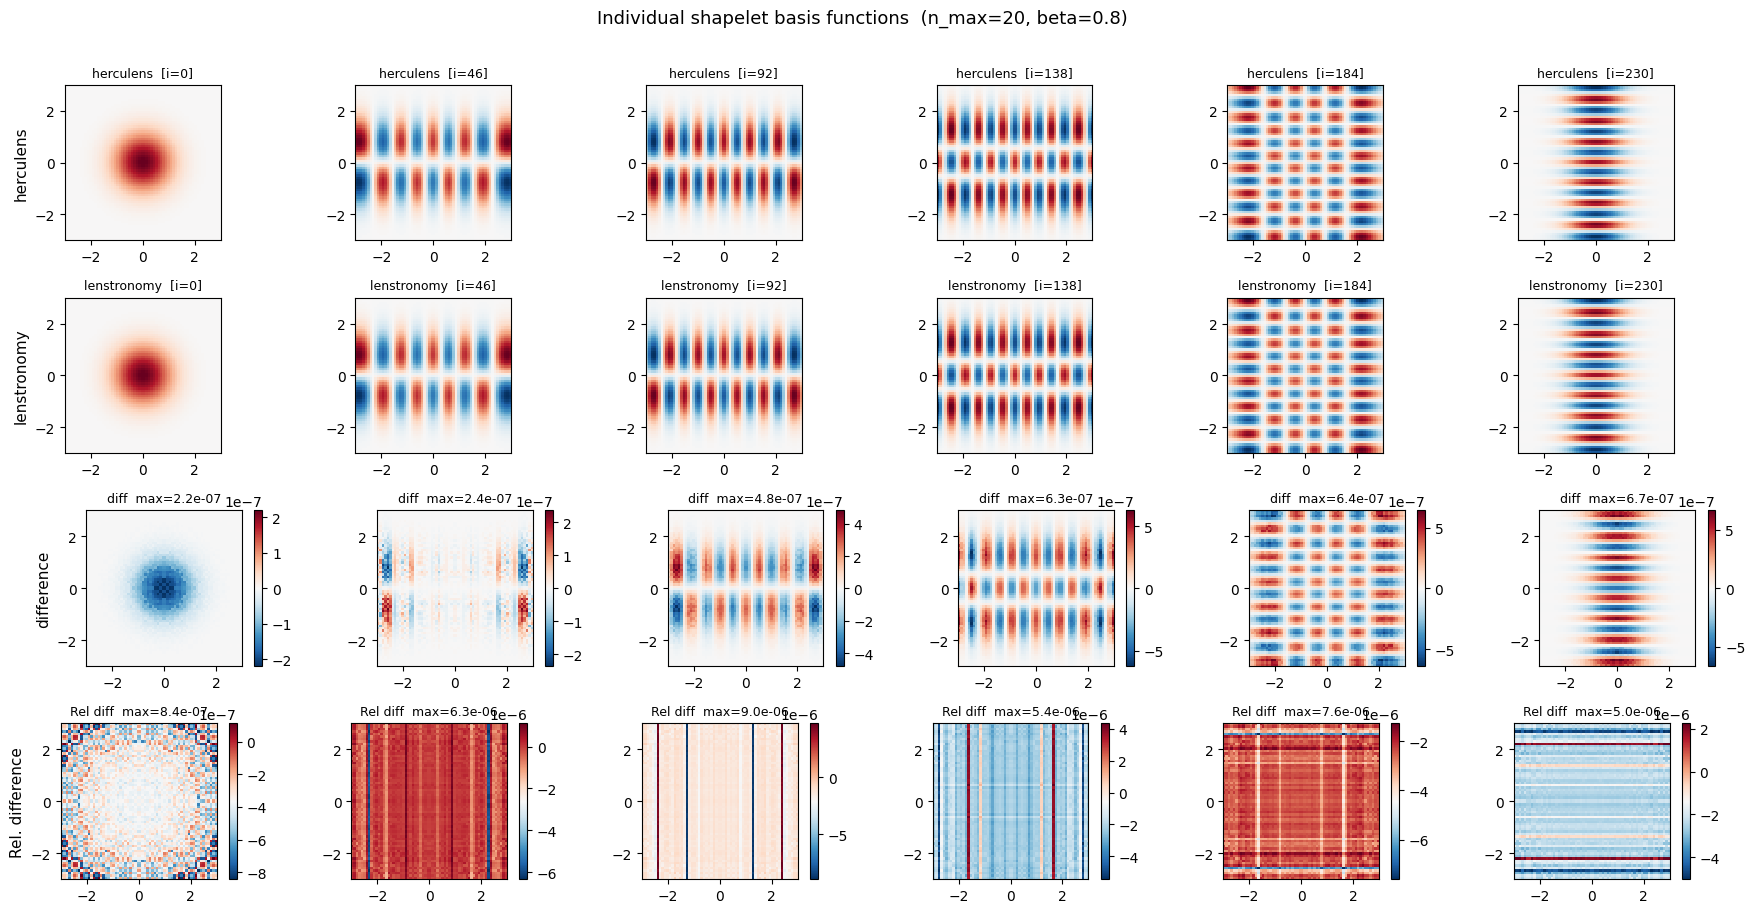

In [6]:
# Pick 6 basis functions spread across the index range
indices_to_show = np.linspace(0, n_amps - 1, 6, dtype=int)

fig, axes = plt.subplots(4, len(indices_to_show), figsize=(18, 9))

for col, i in enumerate(indices_to_show):
    amps_i = np.zeros(n_amps); amps_i[i] = 1.0

    herc_img = np.array(herc_model.function(
        x_flat, y_flat, beta=beta,
        center_x=center_x, center_y=center_y,
        amps=jnp.array(amps_i),
    )).reshape(n_pix, n_pix)

    lst_img = lst_model.function(
        x_flat, y_flat, amp=amps_i, n_max=n_max,
        beta=beta, center_x=center_x, center_y=center_y,
    ).reshape(n_pix, n_pix)

    diff_img = herc_img - lst_img
    rel_diff = (herc_img - lst_img) / lst_img
    vmax = np.max(np.abs([herc_img, lst_img]))
    vmax_diff = np.max(np.abs(diff_img)) or 1e-12
    ext = [-fov, fov, -fov, fov]

    axes[0, col].imshow(herc_img, extent=ext, origin='lower',
                        cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    axes[0, col].set_title(f"herculens  [i={i}]", fontsize=9)

    axes[1, col].imshow(lst_img, extent=ext, origin='lower',
                        cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    axes[1, col].set_title(f"lenstronomy  [i={i}]", fontsize=9)

    im = axes[2, col].imshow(diff_img, extent=ext, origin='lower',
                             cmap='RdBu_r', vmin=-vmax_diff, vmax=vmax_diff)
    axes[2, col].set_title(f"diff  max={vmax_diff:.1e}", fontsize=9)
    plt.colorbar(im, ax=axes[2, col], fraction=0.046)

    im = axes[3, col].imshow(rel_diff, extent=ext, origin='lower',
                             cmap='RdBu_r')
    axes[3, col].set_title(f"Rel diff  max={np.max(np.abs(rel_diff)):.1e}", fontsize=9)
    plt.colorbar(im, ax=axes[3, col])

axes[0, 0].set_ylabel("herculens", fontsize=11)
axes[1, 0].set_ylabel("lenstronomy", fontsize=11)
axes[2, 0].set_ylabel("difference", fontsize=11)
axes[3, 0].set_ylabel("Rel. difference", fontsize=11)

plt.suptitle(f"Individual shapelet basis functions  (n_max={n_max}, beta={beta})",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 2 — Full shapelet set with random amplitudes

In [7]:
rng  = np.random.default_rng(seed=42)
amps = rng.standard_normal(n_amps)

# herculens
herc_full = np.array(herc_model.function(
    x_flat, y_flat,
    beta=beta, center_x=center_x, center_y=center_y,
    amps=jnp.array(amps),
)).reshape(n_pix, n_pix)

# lenstronomy
lst_full = lst_model.function(
    x_flat, y_flat,
    amp=amps, n_max=n_max,
    beta=beta, center_x=center_x, center_y=center_y,
).reshape(n_pix, n_pix)

diff_full = herc_full - lst_full
print(f"Max absolute error (full model) : {np.max(np.abs(diff_full)):.2e}")
print(f"RMS error          (full model) : {np.sqrt(np.mean(diff_full**2)):.2e}")
print(f"Relative RMS error (full model) : {np.sqrt(np.mean(diff_full**2)) / np.sqrt(np.mean(lst_full**2)):.2e}")

Max absolute error (full model) : 9.16e-06
RMS error          (full model) : 2.46e-06
Relative RMS error (full model) : 1.71e-06


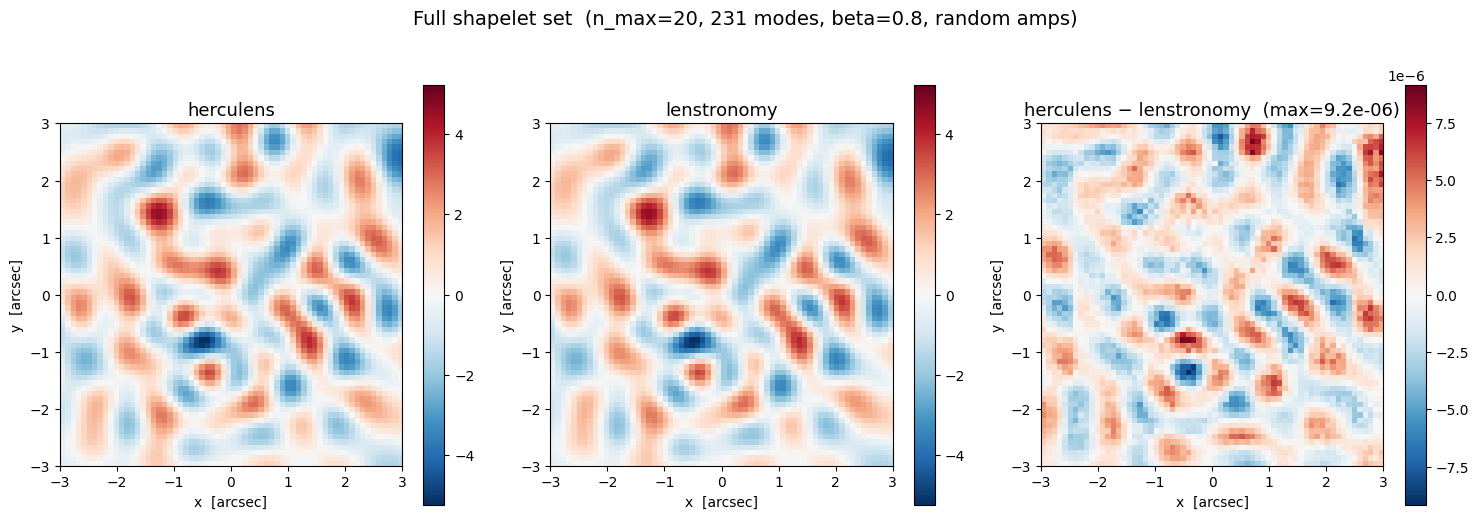

In [8]:
ext = [-fov, fov, -fov, fov]
vmax      = np.max(np.abs([herc_full, lst_full]))
vmax_diff = np.max(np.abs(diff_full)) or 1e-12

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

im0 = axes[0].imshow(herc_full, extent=ext, origin='lower',
                     cmap='RdBu_r', vmin=-vmax, vmax=vmax)
axes[0].set_title("herculens", fontsize=13)
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(lst_full, extent=ext, origin='lower',
                     cmap='RdBu_r', vmin=-vmax, vmax=vmax)
axes[1].set_title("lenstronomy", fontsize=13)
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(diff_full, extent=ext, origin='lower',
                     cmap='RdBu_r', vmin=-vmax_diff, vmax=vmax_diff)
axes[2].set_title(f"herculens − lenstronomy  (max={vmax_diff:.1e})", fontsize=13)
plt.colorbar(im2, ax=axes[2])

for ax in axes:
    ax.set_xlabel("x  [arcsec]")
    ax.set_ylabel("y  [arcsec]")

plt.suptitle(
    f"Full shapelet set  (n_max={n_max}, {n_amps} modes, beta={beta}, random amps)",
    fontsize=14, y=1.02
)
plt.tight_layout()
plt.show()

## 3 — Numerical assertions

Hard checks that confirm agreement to floating-point precision.

In [9]:
tol_abs = 2e-5   # float32 arithmetic limits precision to ~1e-7, but lenstronomy uses float64

# 1. Every individual basis function
for i in range(n_amps):
    amps_i = np.zeros(n_amps); amps_i[i] = 1.0
    herc_out = np.array(herc_model.function(
        x_flat, y_flat, beta=beta,
        center_x=center_x, center_y=center_y,
        amps=jnp.array(amps_i),
    ))
    lst_out = lst_model.function(
        x_flat, y_flat, amp=amps_i, n_max=n_max,
        beta=beta, center_x=center_x, center_y=center_y,
    )
    err = np.max(np.abs(herc_out - lst_out))
    assert err < tol_abs, f"Basis function {i}: max error {err:.2e} exceeds tolerance {tol_abs:.2e}"

# 2. Full model
err_full = np.max(np.abs(diff_full))
assert err_full < tol_abs, f"Full model: max error {err_full:.2e} exceeds tolerance {tol_abs:.2e}"

print(f"All assertions passed  (tolerance = {tol_abs:.0e})")

All assertions passed  (tolerance = 2e-05)


## 4 — Execution time benchmark

Timing comparison between herculens (JAX) and lenstronomy (NumPy) for the full
shapelet set. The herculens call is JIT-compiled by JAX, so we run it once first
to trigger compilation, then time only the compiled execution.

In [10]:
import timeit

amps_bench     = rng.standard_normal(n_amps)
amps_bench_jnp = jnp.array(amps_bench)

# Warm-up: trigger JIT compilation (not included in timing)
_ = herc_model.function(
    x_flat, y_flat, beta=beta,
    center_x=center_x, center_y=center_y,
    amps=amps_bench_jnp,
).block_until_ready()

n_repeats = 200

t_herc = timeit.timeit(
    lambda: herc_model.function(
        x_flat, y_flat, beta=beta,
        center_x=center_x, center_y=center_y,
        amps=amps_bench_jnp,
    ).block_until_ready(),
    number=n_repeats,
) / n_repeats

t_lst = timeit.timeit(
    lambda: lst_model.function(
        x_flat, y_flat,
        amp=amps_bench, n_max=n_max,
        beta=beta, center_x=center_x, center_y=center_y,
    ),
    number=n_repeats,
) / n_repeats

print(f"Grid        : {n_pix}×{n_pix} = {n_pix**2} pixels")
print(f"n_max       : {n_max}  ({n_amps} modes)")
print(f"herculens   : {t_herc*1e3:.3f} ms  (mean over {n_repeats} calls, JIT-compiled)")
print(f"lenstronomy : {t_lst*1e3:.3f} ms  (mean over {n_repeats} calls)")
print(f"Speed-up    : {t_lst/t_herc:.1f}×")

Grid        : 64×64 = 4096 pixels
n_max       : 20  (231 modes)
herculens   : 7.394 ms  (mean over 200 calls, JIT-compiled)
lenstronomy : 3.442 ms  (mean over 200 calls)
Speed-up    : 0.5×


## 5 — Off-centre model

Quick sanity check that the centroid offset is handled the same way in both implementations.

In [11]:
cx, cy = 0.3, -0.5
amps_rand = rng.standard_normal(n_amps)

herc_off = np.array(herc_model.function(
    x_flat, y_flat, beta=beta,
    center_x=cx, center_y=cy,
    amps=jnp.array(amps_rand),
)).reshape(n_pix, n_pix)

lst_off = lst_model.function(
    x_flat, y_flat, amp=amps_rand, n_max=n_max,
    beta=beta, center_x=cx, center_y=cy,
).reshape(n_pix, n_pix)

err_off = np.max(np.abs(herc_off - lst_off))
print(f"Off-centre model: max absolute error = {err_off:.2e}")
assert err_off < tol_abs, f"Off-centre: max error {err_off:.2e} exceeds tolerance"
print("Assertion passed.")

Off-centre model: max absolute error = 1.04e-05
Assertion passed.


## 6 — Interpolated mode

The shapelet backend supports `interpolate=True`, which precomputes `phi_n(t)` on a
regular grid at construction time and uses linear interpolation at call time instead
of running the full Hermite recursion.  This trades a small approximation error for
faster evaluation (and a shallower JAX compute graph).

Here we:
1. Verify the approximation error is within acceptable bounds vs both the exact mode
   and lenstronomy.
2. Compare timing: exact recursion vs interpolated vs lenstronomy.
3. Run hard assertions on the interpolated model.

In [12]:
# Instantiate the interpolated-mode backend
herc_model_interp = HercShapelets(n_max=n_max, interpolate=True)
print(f"Interpolated model ready  (n_grid=6000, grid_limit=6.0, n_layers={herc_model_interp.num_amplitudes})")

Interpolated model ready  (n_grid=6000, grid_limit=6.0, n_layers=231)


Interpolated vs exact herculens:
  Max abs error : 6.01e-05
  RMS error     : 1.13e-05

Interpolated vs lenstronomy:
  Max abs error : 6.92e-05
  RMS error     : 1.34e-05


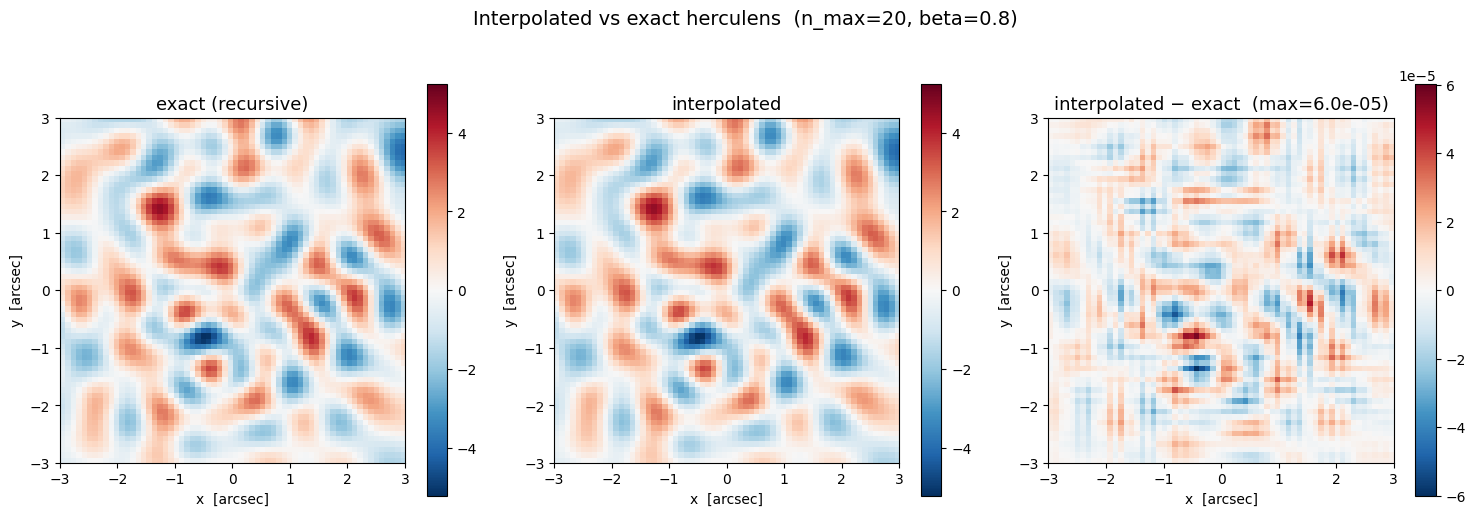

In [13]:
# --- Accuracy: interpolated vs exact herculens and vs lenstronomy ---
interp_full = np.array(herc_model_interp.function(
    x_flat, y_flat,
    beta=beta, center_x=center_x, center_y=center_y,
    amps=jnp.array(amps),
)).reshape(n_pix, n_pix)

diff_interp_vs_exact = interp_full - herc_full
diff_interp_vs_lst   = interp_full - lst_full

print("Interpolated vs exact herculens:")
print(f"  Max abs error : {np.max(np.abs(diff_interp_vs_exact)):.2e}")
print(f"  RMS error     : {np.sqrt(np.mean(diff_interp_vs_exact**2)):.2e}")
print()
print("Interpolated vs lenstronomy:")
print(f"  Max abs error : {np.max(np.abs(diff_interp_vs_lst)):.2e}")
print(f"  RMS error     : {np.sqrt(np.mean(diff_interp_vs_lst**2)):.2e}")

# Visual
ext      = [-fov, fov, -fov, fov]
vmax     = np.max(np.abs([herc_full, interp_full]))
vd_exact = np.max(np.abs(diff_interp_vs_exact)) or 1e-12
vd_lst   = np.max(np.abs(diff_interp_vs_lst))   or 1e-12

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

im0 = axes[0].imshow(herc_full, extent=ext, origin='lower', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
axes[0].set_title("exact (recursive)", fontsize=13)
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(interp_full, extent=ext, origin='lower', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
axes[1].set_title("interpolated", fontsize=13)
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(diff_interp_vs_exact, extent=ext, origin='lower',
                     cmap='RdBu_r', vmin=-vd_exact, vmax=vd_exact)
axes[2].set_title(f"interpolated − exact  (max={vd_exact:.1e})", fontsize=13)
plt.colorbar(im2, ax=axes[2])

for ax in axes:
    ax.set_xlabel("x  [arcsec]"); ax.set_ylabel("y  [arcsec]")

plt.suptitle(f"Interpolated vs exact herculens  (n_max={n_max}, beta={beta})",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [14]:
import timeit as _timeit   # already imported above, but safe to re-import

# Warm-up for interpolated model
_ = herc_model_interp.function(
    x_flat, y_flat, beta=beta,
    center_x=center_x, center_y=center_y,
    amps=amps_bench_jnp,
).block_until_ready()

n_repeats = 200

t_exact = _timeit.timeit(
    lambda: herc_model.function(
        x_flat, y_flat, beta=beta,
        center_x=center_x, center_y=center_y,
        amps=amps_bench_jnp,
    ).block_until_ready(),
    number=n_repeats,
) / n_repeats

t_interp = _timeit.timeit(
    lambda: herc_model_interp.function(
        x_flat, y_flat, beta=beta,
        center_x=center_x, center_y=center_y,
        amps=amps_bench_jnp,
    ).block_until_ready(),
    number=n_repeats,
) / n_repeats

t_lst_bench = _timeit.timeit(
    lambda: lst_model.function(
        x_flat, y_flat,
        amp=amps_bench, n_max=n_max,
        beta=beta, center_x=center_x, center_y=center_y,
    ),
    number=n_repeats,
) / n_repeats

print(f"Grid   : {n_pix}×{n_pix} = {n_pix**2} pixels   |   n_max={n_max} ({n_amps} modes)")
print(f"herculens (exact)        : {t_exact*1e3:.3f} ms")
print(f"herculens (interpolated) : {t_interp*1e3:.3f} ms   ({t_exact/t_interp:.1f}× vs exact)")
print(f"lenstronomy              : {t_lst_bench*1e3:.3f} ms")

Grid   : 64×64 = 4096 pixels   |   n_max=20 (231 modes)
herculens (exact)        : 7.378 ms
herculens (interpolated) : 2.668 ms   (2.8× vs exact)
lenstronomy              : 3.409 ms


In [15]:
# Hard assertions for the interpolated mode
tol_interp = 1e-4   # interpolation error is larger than float32 arithmetic rounding

err_interp_vs_exact = np.max(np.abs(diff_interp_vs_exact))
err_interp_vs_lst   = np.max(np.abs(diff_interp_vs_lst))

assert err_interp_vs_exact < tol_interp, (
    f"Interpolated vs exact: max error {err_interp_vs_exact:.2e} exceeds {tol_interp:.0e}"
)
assert err_interp_vs_lst < tol_interp, (
    f"Interpolated vs lenstronomy: max error {err_interp_vs_lst:.2e} exceeds {tol_interp:.0e}"
)

print(f"All interpolated-mode assertions passed  (tolerance = {tol_interp:.0e})")
print(f"  interp vs exact       : {err_interp_vs_exact:.2e}")
print(f"  interp vs lenstronomy : {err_interp_vs_lst:.2e}")

All interpolated-mode assertions passed  (tolerance = 1e-04)
  interp vs exact       : 6.01e-05
  interp vs lenstronomy : 6.92e-05
